In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib 

import pandas as pd
import torch.nn as nn
import torch.optim as optim

import xarray as xr

import torch.nn as nn
import torch.optim as optim
import torch

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

import seaborn as sns

# Load and preprocess data
We want to determine the low cloud cover based on other weather fields

In [3]:
df = xr.open_dataset('../projects/RiverStreamflow/data/61X13X0.nc',).to_dataframe().dropna().loc['2012':]
# df['Snow_presence'] = 1*(df.Snowdepth>0)
# df[['Tmin_d-1','Tmax_d-1','Tmean_d-1','wind_d-1','Pr_d-1']] = df[['Tmin','Tmax','Tmean','wind','Pr']].shift(1)
# df=df.dropna()
X = df[['air_pressure_at_sea_level','low_type_cloud_area_fraction',
        'relative_humidity_2m',
       'surface_net_longwave_radiation', 'surface_net_shortwave_radiation',
        'precipitation_amount_hourly',
       'wind_direction', 'wind_speed', 
       'medium_type_cloud_area_fraction']]
y = df['air_temperature_2m']

In [ ]:
y.plot()

# Split train and test
We split the data into two parts 

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X,y,shuffle=True)

# Define model

In [60]:
from sklearn.linear_model import LinearRegression
regr = LinearRegression()
regr = regr.fit(X_train, y_train)

# fig, ax = plt.subplots(dpi=300)
# tree.plot_tree(clf, feature_names=X.columns,ax=ax, class_names=['No snow','Snow'],filled=True);

# Evaluate the model on test data

Text(0.5, 1.0, 'RMSE=5.04 K')

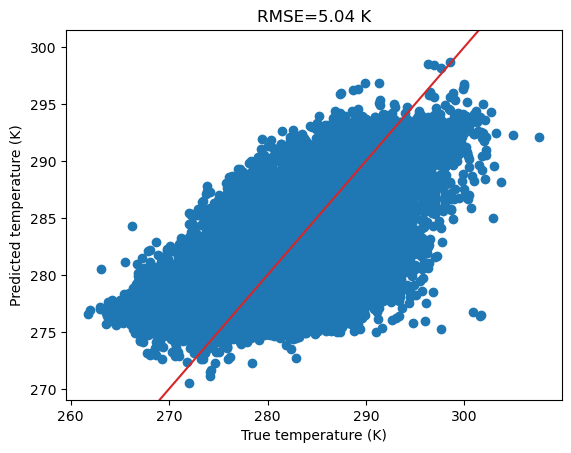

In [64]:
pred_test = regr.predict(X_test)
fig, ax = plt.subplots()
ax.scatter(y_test,pred_test)
ax.axline((300,300), slope=1, color='C3')
ax.set_ylabel('Predicted temperature (K)')
ax.set_xlabel('True temperature (K)')

from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test,pred_test))
ax.set_title(f"RMSE={rmse:.02f} K")